# Relatório Final – Métodos Computacionais para Economia

# Competitividade do Etanol vs. Gasolina e Consumo de Etanol no Brasil

## 1. Introdução
Veículos flex fuel permitem substituição entre gasolina e etanol. Pela popular "regra dos 70%", o etanol tende a ser vantajoso quando custa menos de 70% do preço da gasolina.

**Pergunta:** períodos de maior competitividade do etanol coincidem com maior consumo?

## 2. Hipótese Empírica

**Hipótese:** quanto menor o preço relativo do etanol, maior seu consumo.

Preço Relativo = 𝑷𝒓𝒆ç𝒐 𝒅𝒐 𝑬𝒕𝒂𝒏𝒐𝒍/𝑷𝒓𝒆ç𝒐 𝒅𝒂 𝑮𝒂𝒔𝒐𝒍𝒊𝒏𝒂

## 3. Dados
Bases públicas da ANP.

**Preços (2018–2026):** gasolina comum e etanol hidratado.

**Vendas:** volumes mensais de etanol hidratado e gasolina C, agregados nacionalmente.

## 4. Construção da Base
1. Importação e limpeza dos dados da ANP.
2. Agregação mensal dos preços.
3. Agregação mensal das vendas.
4. Integração (merge) das bases por período.
5. Construção das variáveis:
   - preço relativo etanol/gasolina;
   - consumo de etanol;
   - participação do etanol;
   - indicador de competitividade (< 0,70).

In [ ]:
import pandas as pd
import requests
from io import StringIO
import time

def baixar_csv(url, tentativas=5, sep=";", encoding="latin1", compression=None):
    for i in range(tentativas):
        try:
            r = requests.get(url, timeout=60)
            r.raise_for_status()
            if compression == "zip":
                from io import BytesIO
                return pd.read_csv(BytesIO(r.content), sep=sep, encoding=encoding, compression="zip")
            return pd.read_csv(StringIO(r.content.decode(encoding)), sep=sep)
        except Exception as e:
            print(f"Tentativa {i+1} falhou: {e}")
            time.sleep(3)
    raise Exception(f"Falhou após {tentativas} tentativas: {url}")

# 2018 a 2021
bases_18_21 = []
for ano in range(2018, 2022):
    for semestre in [1, 2]:
        url = f"https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/ca/ca-{ano}-0{semestre}.csv"
        df = baixar_csv(url)
        bases_18_21.append(df)
        print(f"OK: {ano} S{semestre}")

OK: 2018 S1
OK: 2018 S2
OK: 2019 S1
OK: 2019 S2
OK: 2020 S1


C:\Users\mtl1\AppData\Local\Temp\ipykernel_12660\2367107770.py:16: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, sep=";", encoding="latin1")


OK: 2020 S2
OK: 2021 S1
OK: 2021 S2


In [ ]:
bases_22_25 = []

# Itera sobre cada ano de 2022 a 2025
for ano in range(2022, 2026):
    for semestre in [1, 2]:

        # O semestre 1 de 2022 tem um nome de arquivo diferente dos demais (exceção na ANP)
        if ano == 2022 and semestre == 1:
            url = "https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/ca/precos-semestrais-ca.zip"
        else:
            # A partir do 2º semestre de 2022, os arquivos estão compactados em .zip
            url = f"https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/ca/ca-{ano}-0{semestre}.zip"

        # compression="zip" instrui o pandas a descompactar automaticamente antes de ler
        df = pd.read_csv(url, sep=";", encoding="latin1", compression="zip")

        bases_22_25.append(df)

        print(f"OK: {ano} S{semestre}")


OK: 2022 S1
OK: 2022 S2
OK: 2023 S1
OK: 2023 S2
OK: 2024 S1
OK: 2024 S2


C:\Users\mtl1\AppData\Local\Temp\ipykernel_12660\953780937.py:15: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, sep=";", encoding="latin1", compression="zip")


OK: 2025 S1
OK: 2025 S2


In [ ]:
bases_26 = []

# Em 2026 a ANP mudou o formato: arquivos mensais em vez de semestrais
urls_2026 = [
    "https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsan/2026/01-dados-abertos-precos-gasolina-etanol.csv",
    "https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsan/2026/02-cados-abertos-preco-gasolina-etanol.csv",
    "https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsan/2026/03-dados-abertos-precos-gasolina-etanol.csv"
]

# Itera sobre cada URL mensal de 2026 e carrega o CSV correspondente
for url in urls_2026:
    df = pd.read_csv(url, sep=";", encoding="latin1")
    bases_26.append(df)
    print("OK: 2026 mensal")


OK: 2026 mensal
OK: 2026 mensal
OK: 2026 mensal


In [ ]:
# Concatena todas as listas em um único DataFrame ignorando os índices originais
# (ignore_index=True evita índices duplicados ao juntar bases de períodos diferentes)
dados = pd.concat(bases_18_21 + bases_22_25 + bases_26, ignore_index=True)
dados


,ï»¿Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira,Regiao - Sigla
0,NE,BA,SALVADOR,PETROBRAS DISTRIBUIDORA S.A.,34.274.233/0015-08,RUA EDISTIO PONDE,474,NaN,STIEP,41770-395,GNV,02/01/2018,"2,37","1,7383",R$ / mÂ³,PETROBRAS DISTRIBUIDORA S.A.,NaN
1,NE,BA,SALVADOR,PETROBRAS DISTRIBUIDORA S.A.,34.274.233/0015-08,RUA EDISTIO PONDE,474,NaN,STIEP,41770-395,DIESEL S10,02/01/2018,"3,24","3,1366",R$ / litro,PETROBRAS DISTRIBUIDORA S.A.,NaN
2,NE,BA,SALVADOR,PETROBRAS DISTRIBUIDORA S.A.,34.274.233/0015-08,RUA EDISTIO PONDE,474,NaN,STIEP,41770-395,ETANOL,02/01/2018,"2,93","2,6194",R$ / litro,PETROBRAS DISTRIBUIDORA S.A.,NaN
3,NE,BA,SALVADOR,PETROBRAS DISTRIBUIDORA S.A.,34.274.233/0015-08,RUA EDISTIO PONDE,474,NaN,STIEP,41770-395,GASOLINA,02/01/2018,"3,62","3,6017",R$ / litro,PETROBRAS DISTRIBUIDORA S.A.,NaN
4,S,RS,CANOAS,METROPOLITANO COMERCIO DE COMBUSTIVEIS LTDA,88.587.589/0001-17,AVENIDA GUILHERME SCHELL,6340,NaN,CENTRO,92310-000,GNV,02/01/2018,"2,699",NaN,R$ / mÂ³,BRANCA,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7161185,SE,MG,SAO SEBASTIAO DO PARAISO,AUTO POSTO MM LTDA,57.931.708/0001-83,AVENIDA MONSENHOR MANCINI,254,NaN,CENTRO,37950-006,GASOLINA ADITIVADA,31/03/2026,"6,59",NaN,R$ / litro,VIBRA,NaN
7161186,SE,MG,SAO SEBASTIAO DO PARAISO,AUTO POSTO MM LTDA,57.931.708/0001-83,AVENIDA MONSENHOR MANCINI,254,NaN,CENTRO,37950-006,ETANOL,31/03/2026,"4,59",NaN,R$ / litro,VIBRA,NaN
7161187,SE,MG,BETIM,TNE COMBUSTIVEIS REFINARIA LTDA,38.143.064/0001-14,ESTRADA CONTORNO DA PETROBRAS,1436,NaN,DISTRITO INDUSTRIAL PAULO CAMILO SUL,32669-500,GASOLINA,31/03/2026,"6,27",NaN,R$ / litro,BRANCA,NaN
7161188,SE,MG,BETIM,TNE COMBUSTIVEIS REFINARIA LTDA,38.143.064/0001-14,ESTRADA CONTORNO DA PETROBRAS,1436,NaN,DISTRITO INDUSTRIAL PAULO CAMILO SUL,32669-500,GASOLINA ADITIVADA,31/03/2026,"6,39",NaN,R$ / litro,BRANCA,NaN


In [ ]:
# A coluna "Valor de Venda" veio como texto com vírgula decimal (padrão brasileiro)
# Substituímos a vírgula por ponto e convertemos para float (número com casas decimais)
dados["Valor de Venda"] = (
    dados["Valor de Venda"]
    .str.replace(",", ".")
    .astype(float)
)

# Converte a coluna de data de texto para o tipo datetime do pandas
# dayfirst=True indica que o formato é DD/MM/AAAA (padrão brasileiro)
dados["Data da Coleta"] = pd.to_datetime(
    dados["Data da Coleta"],
    dayfirst=True
)

# Exibe os tipos de cada coluna para confirmar que as conversões funcionaram
dados.dtypes


ï»¿Regiao - Sigla            object
Estado - Sigla               object
Municipio                    object
Revenda                      object
CNPJ da Revenda              object
Nome da Rua                  object
Numero Rua                   object
Complemento                  object
Bairro                       object
Cep                          object
Produto                      object
Data da Coleta       datetime64[ns]
Valor de Venda              float64
Valor de Compra              object
Unidade de Medida            object
Bandeira                     object
Regiao - Sigla               object
dtype: object

In [ ]:
# Filtra apenas os registros de GASOLINA e ETANOL (descarta diesel e outros produtos)
df = dados[dados["Produto"].isin(["GASOLINA", "Gasolina Aditivada", "ETANOL"])]

# Cria uma coluna de período mensal (ex.: "2021-03") a partir da data de coleta
# dt.to_period("M") agrupa datas do mesmo mês, ignorando o dia exato
df["Mes"] = df["Data da Coleta"].dt.to_period("M")

# Calcula o preço médio de venda por mês e por produto
# groupby agrupa as linhas; mean() calcula a média; unstack() pivota os produtos para colunas
tabela = df.groupby(["Mes", "Produto"])["Valor de Venda"].mean().unstack()

print("--- Média do Valor de Venda ---")
print()
print(tabela)


C:\Users\mtl1\AppData\Local\Temp\ipykernel_12660\546623915.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Mes"] = df["Data da Coleta"].dt.to_period("M")


--- Média do Valor de Venda ---

Produto    ETANOL  GASOLINA
Mes                        
2018-01  3.144594  4.219924
2018-02  3.196360  4.237376
2018-03  3.215362  4.231014
2018-04  3.222923  4.257337
2018-05  3.096368  4.348680
...           ...       ...
2025-11  4.444227  6.187876
2025-12  4.530275  6.203292
2026-01  4.708790  6.325559
2026-02  4.768278  6.311746
2026-03  4.864459  6.602842

[98 rows x 2 columns]


In [ ]:
# URL da base de vendas de combustíveis da ANP (volume em m³, de 1990 a 2025)
url_vendas = "https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/vdpb/vendas-derivados-petroleo-e-etanol/vendas-combustiveis-m3-1990-2025.csv"

# Lê o CSV de vendas; decimal="," porque os valores numéricos usam vírgula como separador decimal
vendas = pd.read_csv(
    url_vendas,
    sep=";",
    encoding="latin1",
    decimal=","
)

# Filtra apenas os dois produtos de interesse: gasolina C (vendida nos postos) e etanol hidratado
vendas = vendas[vendas["PRODUTO"].isin(["GASOLINA C", "ETANOL HIDRATADO"])]

vendas


,ï»¿ANO,MÃS,GRANDE REGIÃO,UNIDADE DA FEDERAÃÃO,PRODUTO,VENDAS
0,1990,JAN,REGIÃO NORDESTE,MARANHÃO,ETANOL HIDRATADO,7578.939
1,1990,JUL,REGIÃO CENTRO-OESTE,GOIÃS,ETANOL HIDRATADO,24462.251
2,1990,JUN,REGIÃO CENTRO-OESTE,GOIÃS,ETANOL HIDRATADO,25005.954
3,1990,MAI,REGIÃO CENTRO-OESTE,GOIÃS,ETANOL HIDRATADO,18888.239
4,1990,ABR,REGIÃO CENTRO-OESTE,GOIÃS,ETANOL HIDRATADO,27535.918
...,...,...,...,...,...,...
93523,2026,MAR,REGIÃO NORTE,TOCANTINS,GASOLINA C,38818.900
93524,2026,ABR,REGIÃO NORTE,TOCANTINS,GASOLINA C,38156.400
93525,2026,ABR,REGIÃO CENTRO-OESTE,DISTRITO FEDERAL,GASOLINA C,90545.915
93526,2026,MAR,REGIÃO CENTRO-OESTE,DISTRITO FEDERAL,GASOLINA C,95475.300


In [ ]:
# Renomeia as colunas para nomes mais curtos e legíveis
vendas.columns = ["ANO", "MES", "GRANDE_REGIAO", "UF", "PRODUTO", "VENDAS"]

# Dicionário que converte as abreviações de mês em português para número (ex.: "JAN" → "01")
mapa_meses = {
    "JAN": "01", "FEV": "02", "MAR": "03", "ABR": "04",
    "MAI": "05", "JUN": "06", "JUL": "07", "AGO": "08",
    "SET": "09", "OUT": "10", "NOV": "11", "DEZ": "12"
}

# Cria a coluna "ano_mes" no formato "AAAA-MM" (ex.: "2021-03")
# Isso padroniza o índice temporal para facilitar o join com a tabela de preços
vendas["ano_mes"] = (
    vendas["ANO"].astype(str) + "-" +
    vendas["MES"].map(mapa_meses)   # substitui a abreviação pelo número correspondente
)

# Agrega o volume de vendas somando todas as UFs por mês, região e produto
# as_index=False mantém as colunas de agrupamento como colunas normais (não como índice)
vendas_regiao = (
    vendas
    .groupby(["ano_mes", "GRANDE_REGIAO", "PRODUTO"], as_index=False)["VENDAS"]
    .sum()
)

vendas_regiao


,ano_mes,GRANDE_REGIAO,PRODUTO,VENDAS
0,1990-01,REGIÃO CENTRO-OESTE,ETANOL HIDRATADO,85706.141
1,1990-01,REGIÃO CENTRO-OESTE,GASOLINA C,75534.556
2,1990-01,REGIÃO NORDESTE,ETANOL HIDRATADO,150046.598
3,1990-01,REGIÃO NORDESTE,GASOLINA C,103522.561
4,1990-01,REGIÃO NORTE,ETANOL HIDRATADO,25342.903
...,...,...,...,...
4355,2026-04,REGIÃO NORTE,GASOLINA C,299842.133
4356,2026-04,REGIÃO SUDESTE,ETANOL HIDRATADO,1212386.523
4357,2026-04,REGIÃO SUDESTE,GASOLINA C,1563843.608
4358,2026-04,REGIÃO SUL,ETANOL HIDRATADO,160267.501


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats  # biblioteca para correlações, testes estatísticos e regressão

# Configurações globais de estilo para todos os gráficos do notebook
plt.rcParams.update({
    'figure.dpi': 150,          # resolução alta para os gráficos ficarem nítidos no relatório
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,   # remove a borda do topo dos gráficos (visual mais limpo)
    'axes.spines.right': False, # remove a borda da direita
})

# Constante do limiar de competitividade do etanol em relação à gasolina
# Quando etanol/gasolina < 0,70, o etanol é a escolha economicamente mais eficiente
LIMIAR = 0.70


## Carregamento da base tratada
`tabela`: preços médios mensais.

`vendas_regiao`: vendas mensais por produto e região.

In [ ]:
# ── Preço relativo mensal ────────────────────────────────────────
# Seleciona as colunas de preço de ETANOL e GASOLINA da tabela construída pela dupla de dados
preco_rel = tabela[["ETANOL", "GASOLINA"]].copy()
preco_rel.columns = ["preco_etanol", "preco_gasolina"]

# Calcula o preço relativo: quanto o etanol custa em proporção à gasolina
# Ex.: 0,65 significa que o etanol custa 65% do preço da gasolina naquele mês
preco_rel["preco_relativo"] = preco_rel["preco_etanol"] / preco_rel["preco_gasolina"]

# O índice é do tipo Period (ex.: "2021-03"); converte para Timestamp para compatibilidade com plots
preco_rel.index = preco_rel.index.to_timestamp()

# Remove meses sem dados (caso algum produto não tenha registro naquele período)
preco_rel = preco_rel.dropna()

# ── Consumo nacional mensal de etanol hidratado ──────────────────
# Filtra apenas o etanol hidratado e soma as regiões para obter o total nacional por mês
vendas_etanol = (
    vendas_regiao[vendas_regiao["PRODUTO"] == "ETANOL HIDRATADO"]
    .groupby("ano_mes")["VENDAS"]
    .sum()
    .reset_index()
)
# Converte a coluna "ano_mes" de texto para datetime (necessário para o join por data)
vendas_etanol["ano_mes"] = pd.to_datetime(vendas_etanol["ano_mes"])
vendas_etanol = vendas_etanol.sort_values("ano_mes").set_index("ano_mes")

# ── Consumo nacional mensal de gasolina C ────────────────────────
# Mesmo processo para a gasolina — será usada para calcular a participação do etanol
vendas_gasolina = (
    vendas_regiao[vendas_regiao["PRODUTO"] == "GASOLINA C"]
    .groupby("ano_mes")["VENDAS"]
    .sum()
    .reset_index()
)
vendas_gasolina["ano_mes"] = pd.to_datetime(vendas_gasolina["ano_mes"])
vendas_gasolina = vendas_gasolina.sort_values("ano_mes").set_index("ano_mes")

# ── Base unificada ────────────────────────────────────────────────
# Une preço relativo e consumo de etanol pelo índice de data (how="inner" mantém só meses com ambos)
df_analise = preco_rel[["preco_relativo"]].join(vendas_etanol, how="inner")
df_analise.columns = ["preco_relativo", "consumo_etanol"]

# Adiciona o consumo de gasolina para calcular a participação do etanol no total
df_analise = df_analise.join(vendas_gasolina.rename(columns={"VENDAS": "consumo_gasolina"}), how="left")

# Participação do etanol = consumo_etanol / (consumo_etanol + consumo_gasolina)
# Indica a fatia do etanol no mercado de combustíveis leves a cada mês
df_analise["participacao_etanol"] = (
    df_analise["consumo_etanol"] /
    (df_analise["consumo_etanol"] + df_analise["consumo_gasolina"])
)

print(f"Período analisado: {df_analise.index.min().strftime('%b/%Y')} a {df_analise.index.max().strftime('%b/%Y')}")
print(f"Número de meses: {len(df_analise)}")
df_analise.head()


Período analisado: Jan/2018 a Mar/2026
Número de meses: 98


,preco_relativo,consumo_etanol,consumo_gasolina,participacao_etanol
2018-01-01,0.745178,1377296.221,3389921.849,0.288910
2018-02-01,0.754325,1242878.696,3132420.400,0.284067
2018-03-01,0.759951,1372784.096,3625937.313,0.274627
2018-04-01,0.757028,1286890.469,3374562.564,0.276071
2018-05-01,0.712025,1315822.230,3067245.438,0.300206


## 5.1 Evolução Temporal
Análise conjunta do preço relativo etanol/gasolina e do consumo de etanol. Períodos de maior competitividade tendem a coincidir com maior consumo.

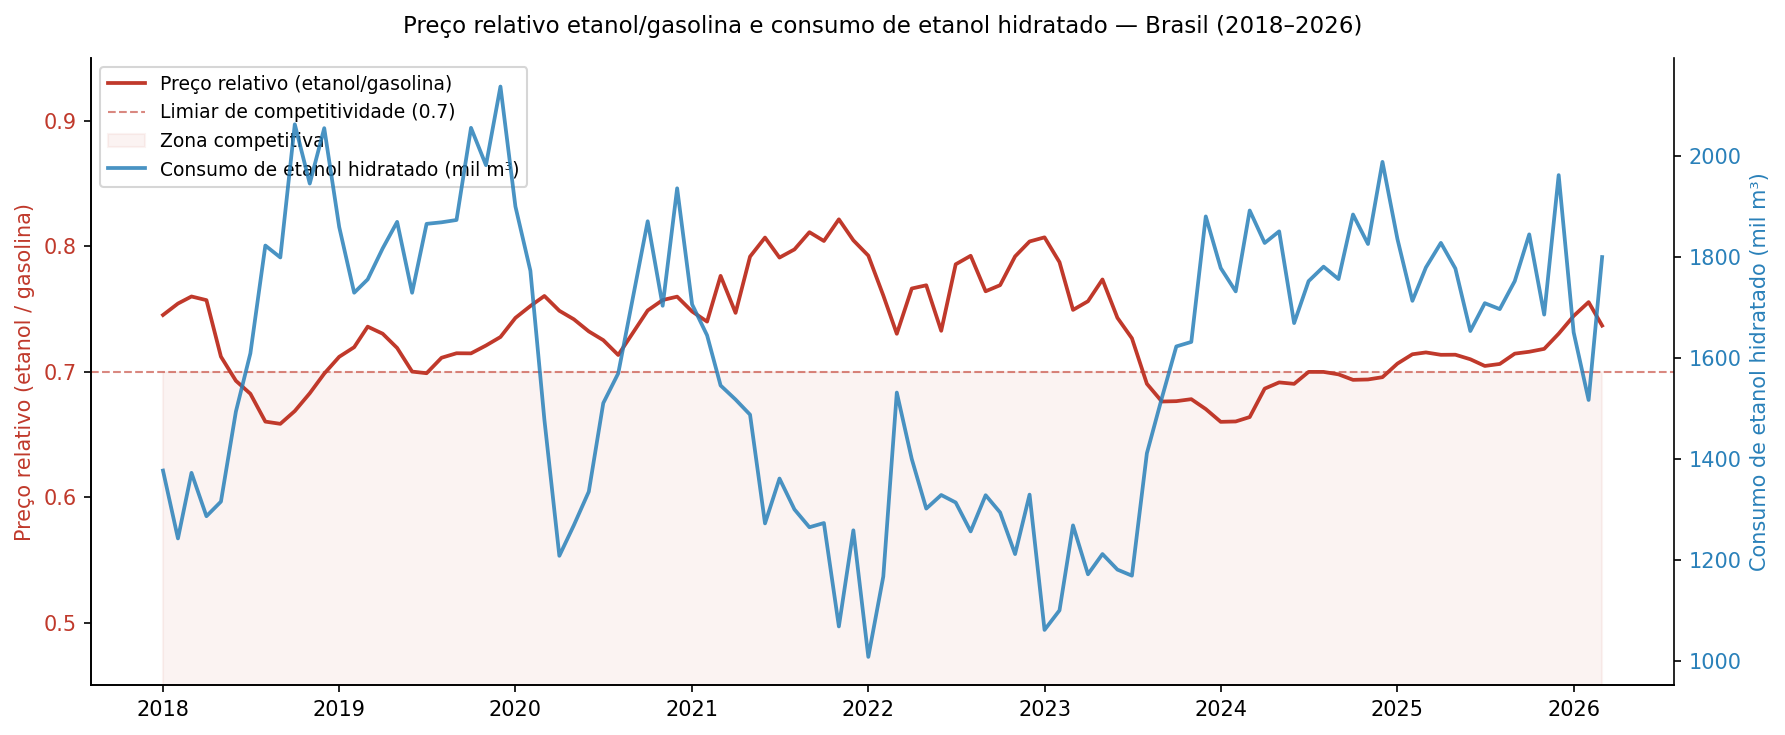

Gráfico salvo: grafico_evolucao_temporal.png


In [ ]:
# Cria uma figura com um único eixo (ax1); tamanho largo para série temporal
fig, ax1 = plt.subplots(figsize=(12, 5))

# ── Eixo esquerdo: preço relativo ────────────────────────────────
cor_preco = "#C0392B"  # vermelho
ax1.plot(df_analise.index, df_analise["preco_relativo"],
         color=cor_preco, linewidth=1.8, label="Preço relativo (etanol/gasolina)")

# Linha horizontal tracejada no limiar 0,70 — referência visual para o consumidor
ax1.axhline(LIMIAR, color=cor_preco, linestyle="--", linewidth=1,
            alpha=0.6, label=f"Limiar de competitividade ({LIMIAR})")

ax1.set_ylabel("Preço relativo (etanol / gasolina)", color=cor_preco)
ax1.tick_params(axis="y", labelcolor=cor_preco)  # colore os números do eixo Y na mesma cor
ax1.set_ylim(0.45, 0.95)  # limita o eixo Y para melhor visualização da variação

# Sombreamento leve abaixo do limiar — zona em que o etanol é a escolha mais barata
ax1.fill_between(df_analise.index, 0, LIMIAR,
                 alpha=0.06, color=cor_preco, label="Zona competitiva")

# ── Eixo direito: consumo de etanol ─────────────────────────────
# twinx() cria um segundo eixo Y compartilhando o mesmo eixo X
ax2 = ax1.twinx()
cor_consumo = "#2980B9"  # azul
ax2.plot(df_analise.index, df_analise["consumo_etanol"] / 1000,  # divide por 1000: m³ → mil m³
         color=cor_consumo, linewidth=1.8, alpha=0.85,
         label="Consumo de etanol hidratado (mil m³)")
ax2.set_ylabel("Consumo de etanol hidratado (mil m³)", color=cor_consumo)
ax2.tick_params(axis="y", labelcolor=cor_consumo)
ax2.spines["right"].set_visible(True)  # reativa a borda direita para o segundo eixo

# ── Legenda unificada dos dois eixos ────────────────────────────
# get_legend_handles_labels() extrai as linhas e rótulos de cada eixo separadamente
linhas1, labels1 = ax1.get_legend_handles_labels()
linhas2, labels2 = ax2.get_legend_handles_labels()
# Combina os dois e exibe em uma legenda única no canto superior esquerdo
ax1.legend(linhas1 + linhas2, labels1 + labels2,
           loc="upper left", fontsize=9, framealpha=0.8)

ax1.set_title("Preço relativo etanol/gasolina e consumo de etanol hidratado — Brasil (2018–2026)",
              fontsize=11, pad=12)
ax1.set_xlabel("")
fig.tight_layout()  # ajusta espaçamentos automaticamente para nada ser cortado
plt.savefig("grafico_evolucao_temporal.png", bbox_inches="tight")
plt.show()
print("Gráfico salvo: grafico_evolucao_temporal.png")


## 5.2 Competitivo vs. Não Competitivo
Comparação entre meses com preço relativo < 0,70 e ≥ 0,70. Resultados na Tabela **Consumo médio de etanol hidratado por grupo (m³)**

In [ ]:
# ── Classificação dos meses ──────────────────────────────────────
# Cria uma coluna categórica baseada no limiar 0,70
# apply() aplica a função lambda a cada valor da coluna "preco_relativo"
df_analise["grupo"] = df_analise["preco_relativo"].apply(
    lambda x: "Competitivo (< 0,70)" if x < LIMIAR else "Não competitivo (≥ 0,70)"
)

# ── Tabela de estatísticas descritivas por grupo ─────────────────
# groupby agrupa os meses pelo grupo; agg() calcula múltiplas estatísticas de uma vez
desc = (
    df_analise
    .groupby("grupo")["consumo_etanol"]
    .agg(
        n_meses="count",       # quantos meses estão em cada grupo
        media="mean",          # consumo médio
        mediana="median",      # mediana (menos sensível a outliers do que a média)
        desvio_padrao="std",   # dispersão dos dados em torno da média
        minimo="min",
        maximo="max"
    )
    .round(0)  # arredonda para número inteiro (m³ não precisa de casas decimais)
)
desc.index.name = "Grupo"
print("Consumo médio de etanol hidratado por grupo (m³)")
print("=" * 60)
print(desc.to_string())
print()


Consumo médio de etanol hidratado por grupo (m³)
                          n_meses      media    mediana  desvio_padrao     minimo     maximo
Grupo                                                                                       
Competitivo (< 0,70)           25  1778459.0  1799251.0       165242.0  1411478.0  2062893.0
Não competitivo (≥ 0,70)       73  1525745.0  1517005.0       283266.0  1008386.0  2137636.0



Consumo médio de etanol cerca de 16,6% maior nos períodos competitivos.

## 5.3 Teste t
Teste de diferença de médias entre os grupos.

- t = 4,21
- p-valor = 0,0001

Rejeita-se a hipótese de igualdade das médias.

In [ ]:

# ── Teste t de Student ───────────────────────────────────────────
# Verifica se a diferença de médias entre os dois grupos é estatisticamente significativa
# Um p-valor < 0,05 indica que a diferença dificilmente se deve ao acaso
grupo_comp  = df_analise.loc[df_analise["grupo"] == "Competitivo (< 0,70)", "consumo_etanol"]
grupo_ncomp = df_analise.loc[df_analise["grupo"] == "Não competitivo (≥ 0,70)", "consumo_etanol"]
t_stat, p_valor = stats.ttest_ind(grupo_comp, grupo_ncomp)
print(f"Teste t (diferença de médias): t = {t_stat:.2f}, p-valor = {p_valor:.4f}")


Teste t (diferença de médias): t = 4.21, p-valor = 0.0001


 O boxplot confirma deslocamento da distribuição para níveis mais elevados.

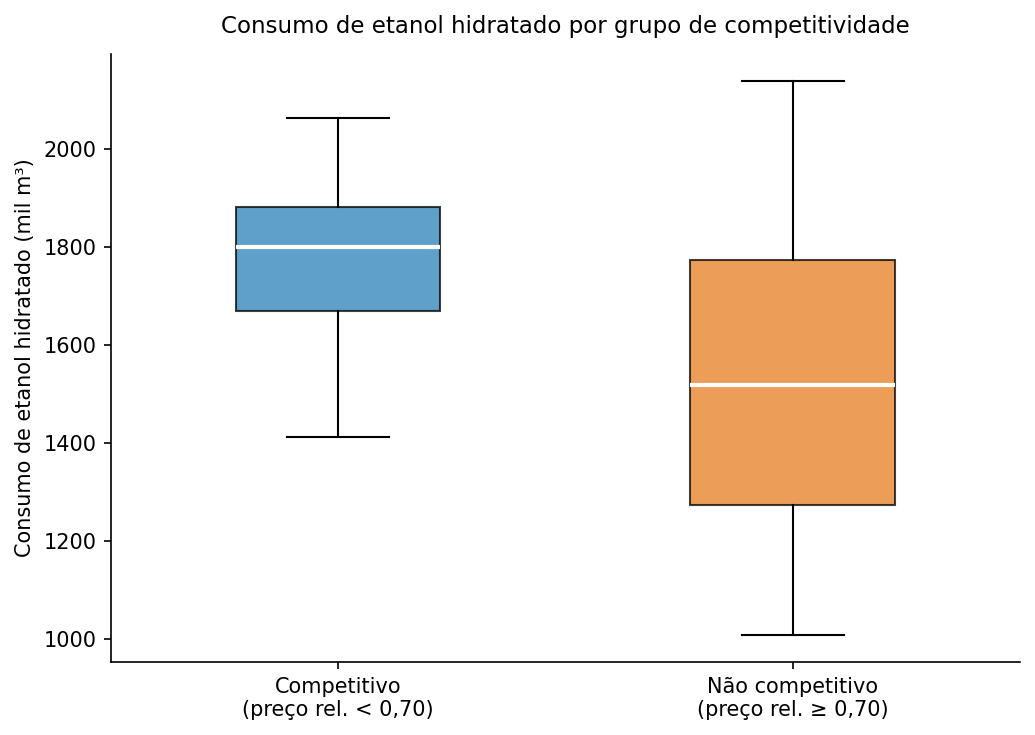

Gráfico salvo: grafico_boxplot_grupos.png


In [ ]:
# ── Boxplot comparativo ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

# Divide por 1000 para exibir em "mil m³" (escala mais legível no gráfico)
grupos = [grupo_comp / 1000, grupo_ncomp / 1000]
labels = ["Competitivo\n(preço rel. < 0,70)", "Não competitivo\n(preço rel. ≥ 0,70)"]
cores  = ["#2980B9", "#E67E22"]

# patch_artist=True permite colorir as caixas; medianprops define o estilo da linha da mediana
bp = ax.boxplot(grupos, patch_artist=True, widths=0.45,
                medianprops=dict(color="white", linewidth=2))

# Aplica a cor de cada grupo à caixa correspondente
for patch, cor in zip(bp["boxes"], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.75)

ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Consumo de etanol hidratado (mil m³)", fontsize=10)
ax.set_title("Consumo de etanol hidratado por grupo de competitividade", fontsize=11, pad=10)
fig.tight_layout()
plt.savefig("grafico_boxplot_grupos.png", bbox_inches="tight")
plt.show()
print("Gráfico salvo: grafico_boxplot_grupos.png")


## 5.4 Correlação
Avaliação da relação entre preço relativo e consumo por correlações de Pearson e Spearman.

In [ ]:
# ── Coeficientes de correlação ───────────────────────────────────
# Pearson mede a correlação linear entre as duas variáveis (assume distribuição normal)
# Retorna o coeficiente r e o p-valor (probabilidade de r ser zero na população)
pearson_r, pearson_p  = stats.pearsonr(df_analise["preco_relativo"], df_analise["consumo_etanol"])

# Spearman mede correlação por postos (ranks), sem assumir linearidade
# É mais robusta a outliers e não depende de distribuição normal
spearman_r, spearman_p = stats.spearmanr(df_analise["preco_relativo"], df_analise["consumo_etanol"])

print(f"Correlação de Pearson:  r = {pearson_r:.3f}  (p = {pearson_p:.4f})")
print(f"Correlação de Spearman: r = {spearman_r:.3f}  (p = {spearman_p:.4f})")




Correlação de Pearson:  r = -0.685  (p = 0.0000)
Correlação de Spearman: r = -0.648  (p = 0.0000)


Ambos os coeficientes possuem p < 0,001. Há relação negativa moderadamente forte: aumentos do preço relativo estão associados a menor consumo de etanol.

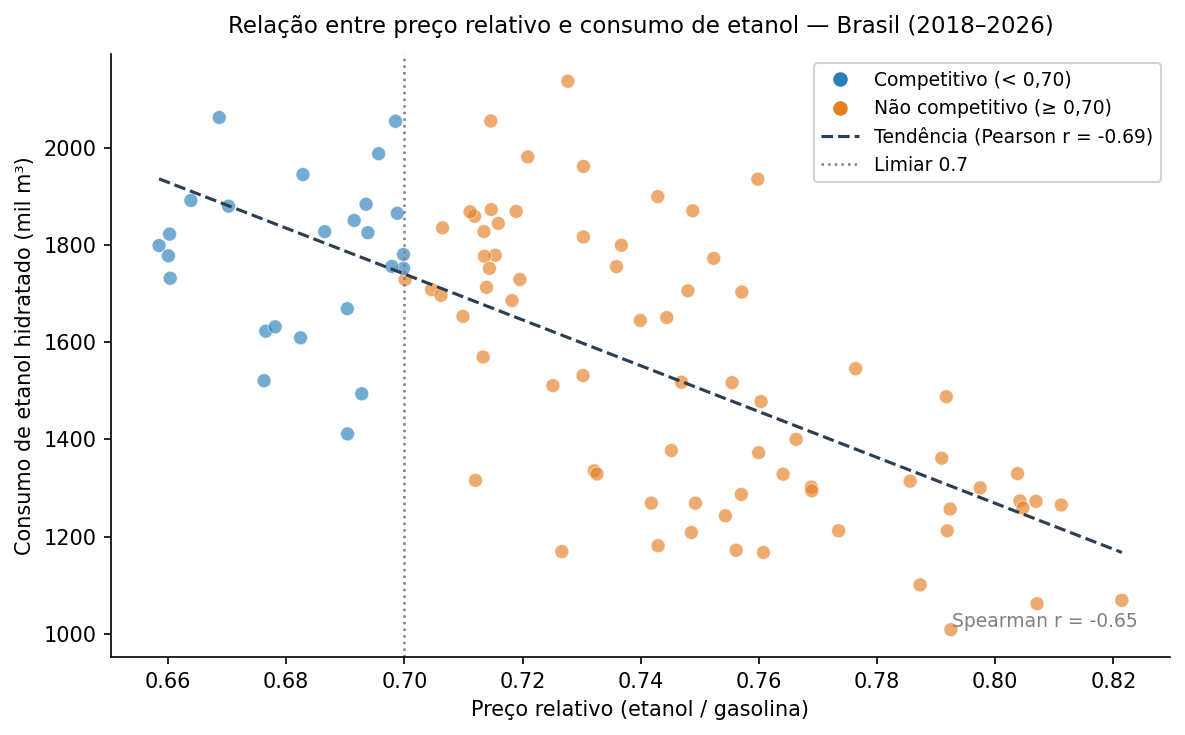

Gráfico salvo: grafico_dispersao_correlacao.png


In [ ]:
# ── Linha de tendência via regressão linear simples ──────────────
# linregress ajusta y = slope*x + intercept minimizando o erro quadrático
# *_ descarta os outros valores retornados (r², p-valor, erro padrão)
slope, intercept, *_ = stats.linregress(df_analise["preco_relativo"], df_analise["consumo_etanol"])

# Dois pontos são suficientes para desenhar uma reta: mínimo e máximo de x
x_linha = pd.Series([df_analise["preco_relativo"].min(), df_analise["preco_relativo"].max()])
y_linha = slope * x_linha + intercept  # aplica a equação da reta

# ── Diagrama de dispersão ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# Mapeia cada mês para a cor do seu grupo (azul = competitivo, laranja = não competitivo)
cores_grupo = df_analise["grupo"].map({
    "Competitivo (< 0,70)": "#2980B9",
    "Não competitivo (≥ 0,70)": "#E67E22"
})

# Cada ponto representa um mês: X = preço relativo, Y = consumo de etanol
scatter = ax.scatter(
    df_analise["preco_relativo"],
    df_analise["consumo_etanol"] / 1000,  # converte para mil m³
    c=cores_grupo, alpha=0.65, s=45,      # s=45 define o tamanho dos pontos
    edgecolors="white", linewidths=0.4    # borda branca fina para separar pontos sobrepostos
)

# Linha de tendência (reta ajustada pela regressão linear)
ax.plot(x_linha, y_linha / 1000, color="#2C3E50", linewidth=1.5,
        linestyle="--", label=f"Tendência linear (r = {pearson_r:.2f})")

# Linha vertical no limiar 0,70 — separa visualmente os dois grupos no gráfico
ax.axvline(LIMIAR, color="gray", linestyle=":", linewidth=1.2,
           label=f"Limiar {LIMIAR}")

# ── Legenda manual ───────────────────────────────────────────────
# O scatter não gera legenda automática para cores mapeadas, então criamos manualmente
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2980B9',
           markersize=8, label="Competitivo (< 0,70)"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E67E22',
           markersize=8, label="Não competitivo (≥ 0,70)"),
    Line2D([0], [0], color='#2C3E50', linewidth=1.5, linestyle='--',
           label=f"Tendência (Pearson r = {pearson_r:.2f})"),
    Line2D([0], [0], color='gray', linewidth=1.2, linestyle=':',
           label=f"Limiar {LIMIAR}")
]
ax.legend(handles=legend_elements, fontsize=9, framealpha=0.85)

ax.set_xlabel("Preço relativo (etanol / gasolina)", fontsize=10)
ax.set_ylabel("Consumo de etanol hidratado (mil m³)", fontsize=10)
ax.set_title("Relação entre preço relativo e consumo de etanol — Brasil (2018–2026)",
             fontsize=11, pad=10)

# Exibe o coeficiente de Spearman no canto inferior direito como informação complementar
ax.annotate(f"Spearman r = {spearman_r:.2f}",
            xy=(0.97, 0.05), xycoords="axes fraction",
            ha="right", fontsize=9, color="gray")

fig.tight_layout()
plt.savefig("grafico_dispersao_correlacao.png", bbox_inches="tight")
plt.show()
print("Gráfico salvo: grafico_dispersao_correlacao.png")

## 5.5 Interpretação Econômica
Os resultados são consistentes com a teoria da demanda para bens substitutos. Maior competitividade do etanol incentiva substituição da gasolina e eleva seu consumo.

## 6. Limitações e Conclusão
**Limitações:** análise descritiva, sem inferência causal; ausência de controles como renda, atividade econômica, tributação e fatores regionais.

**Próximos passos:** modelos econométricos e análises por estado.

## 7. Conclusão
Os resultados indicam associação negativa entre preço relativo e consumo de etanol, sugerindo que a competitividade de preços é um determinante relevante da demanda.